<Figure size 640x480 with 0 Axes>

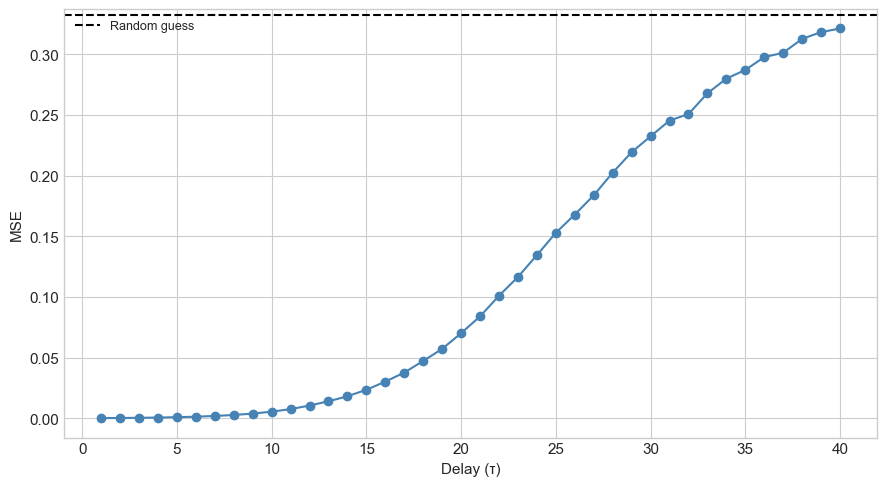

In [2]:

######################################
# Memory performance of the reservoir
######################################

import numpy as np
import matplotlib.pyplot as plt
from reservoirpy.nodes import Reservoir, Ridge
import reservoirpy as rpy


# Specify two seeds, both for numpy and reservoipy. This ensures that while random numbers are used the tests can be reproduced in an exact manner
np.random.seed(55)
rpy.set_seed(55)

# Defining the inputs and the target variables for training
# The input is a sequence of vectors that have five elements each. We define two different lengths for the sequences, which work as the timesteps
i=5000
dim=5

# The delays from 1 to 40
tau=list(range(1, 41))

# Placeholder for MSE values
mse_list=np.zeros(len(tau))

# Making the reservoir
reservoir =Reservoir(500, lr=1.0, sr=0.99, input_scaling=0.1, activation="tanh")  #500 neurons, the leaking rate and spectral radius are defined as 1. The activation function is hyberpolic tangent

s=np.random.uniform(-1, 1, (i, dim)) #Make the sequence (length i). It consists of vectors with dimension of 5. The elements are random numbers that are scaled between -1 and 1
reservoir_states=reservoir.run(s) #Run the reservoir

# We do not want to include initial steps so that the reservoir can settle when trained. We exclude 200 of the steps from the training
reservoir_states=reservoir_states[200:]
input_r = s[200:]  #With this we align the input and the reservoir states

# 80/20 train/test split
split= int(len(reservoir_states) * 0.8)
states_train= reservoir_states[:split]
states_test =reservoir_states[split:]
u_train=input_r[:split]
u_test=input_r[split:]

# Loop through all delay the values
for index2, j in enumerate(tau):
    target_train= u_train[:-j] #Apply the delay
    target_test= u_test[:-j]
    states_train_t= states_train[j:]#Define the delay for the reservoir state
    states_test_t= states_test[j:]
    readout_l= Ridge(ridge=1e-10)#The readout layer in reservoirpy is trained with ridge regression. We want linear readout as we use the Moore-Penrose inverse, so we choose a value close to zero(more stability than exact zero).
    readout_l=readout_l.fit(states_train_t, target_train) #Train the readout layer
    pred= readout_l.run(states_test_t)#Make the predictions
    mse= np.mean((target_test - pred)**2) #Calculate the mean of MSE
    mse_list[index2] = mse#Add the values to the list

# Plot
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 12,
                     "axes.labelsize": 11, "legend.fontsize": 9})
plt.figure()
plt.figure(figsize=(9, 5))
plt.plot(tau, mse_list, marker="o", color="steelblue")

plt.xlabel("Delay (τ)") 
plt.axhline(np.var(input_r), color="black",
            linestyle='--', label="Random guess") 
plt.ylabel("MSE") 
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()